INITIAL SPIN CONDITION
Total Population (N) : 1000
Probability +1    : 0.7500
Probability -1    : 0.2500
Initial M : 0.5000

RANDOM ASSIGN SPIN CONDITION
N_up   : 750
N_down : 250
Actual M : 0.5000



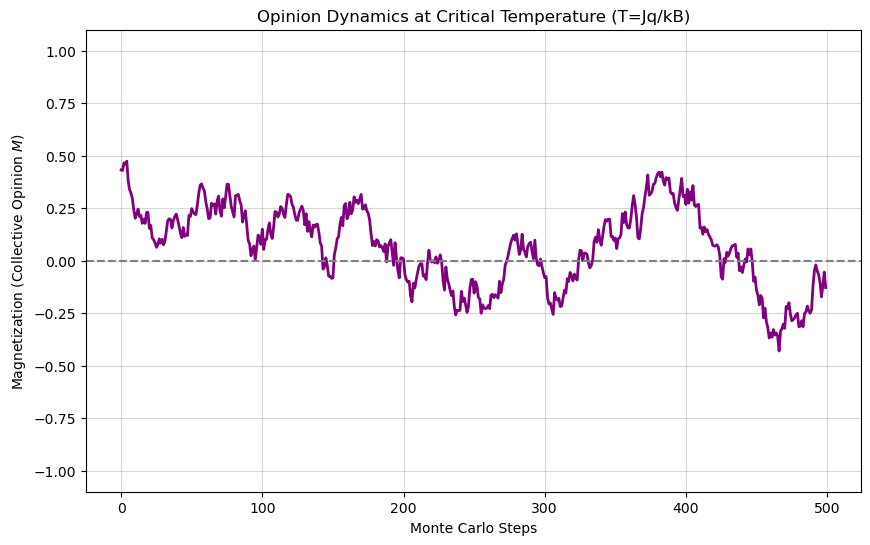

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_glauber_with_data(N_up_initial, N_down_initial, T, h, J, q, steps):
# 1. INITIALIZATION
    N = N_up_initial + N_down_initial
    
# Calculate probability of + and - opininion
    P_up = N_up_initial / N
    P_down = N_down_initial / N
    
# Calculate Initial Magnetization from the data
    M_awal = (N_up_initial - N_down_initial) / N
    
    print(f"INITIAL SPIN CONDITION")
    print(f"Total Population (N) : {N}")
    print(f"Probability +1    : {P_up:.4f}")
    print(f"Probability -1    : {P_down:.4f}")
    print(f"Initial M : {M_awal:.4f}\n")
    
# Assign spin randomly based on probability P_up dan P_down
    spins = np.array([1] * N_up_initial + [-1] * N_down_initial)
    np.random.shuffle(spins)

    N_up = N_up_initial
    N_down = N_down_initial
    
# Calculate the number of assigned up and down spin
    N_up = np.sum(spins == 1)
    N_down = np.sum(spins == -1)
    
    print(f"RANDOM ASSIGN SPIN CONDITION")
    print(f"N_up   : {N_up}")
    print(f"N_down : {N_down}")
    print(f"Actual M : {(N_up - N_down) / N:.4f}\n")

# 2. GLAUBER + MEAN-FIELD SIMULATION
    magnetization_history = []
    kB = 0.6 
    
    for step in range(steps):
        # Inner loop: N flip for each Monte Carlo Step
        for _ in range(N):
            M = (N_up - N_down) / N
            h_eff = h + J * q * M
            
            i = np.random.randint(0, N)
            sigma_i = spins[i]
            
            delta_E = 2 * sigma_i * h_eff
            
            exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))
            P_flip = 1.0 / (1.0 + exp_term)
            
            r = np.random.rand()
            if r < P_flip:
                spins[i] = -sigma_i
                
                if spins[i] == 1:
                    N_up += 1
                    N_down -= 1
                else:
                    N_up -= 1
                    N_down += 1
                    
        magnetization_history.append((N_up - N_down) / N)
        
    return magnetization_history

# Simulation Parameter
# Initial Number of Opinion 
Data_N_up = 750
Data_N_down = 250

# Ising model and Glauber Scheme Parameter
External_field = 0.0 
J_coupling = 0.3     
q_neighbors = 4.0    
Time_steps = 500
Temperature = 2.0

# Run the simulation
M_history = simulate_glauber_with_data(
    N_up_initial=Data_N_up, N_down_initial=Data_N_down, T=Temperature,
    h=External_field, J=J_coupling, 
    q=q_neighbors, steps=Time_steps
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(M_history, color='purple', linewidth=2)
plt.title("Opinion Dynamics at Critical Temperature (T=Jq/kB)")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Magnetization (Collective Opinion $M$)")
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()

INITIAL SPIN CONDITION
Total Population (N) : 1000
Probability +1    : 0.7500
Probability -1    : 0.2500
Initial M : 0.5000

RANDOM ASSIGN SPIN CONDITION
N_up   : 750
N_down : 250
Actual M : 0.5000



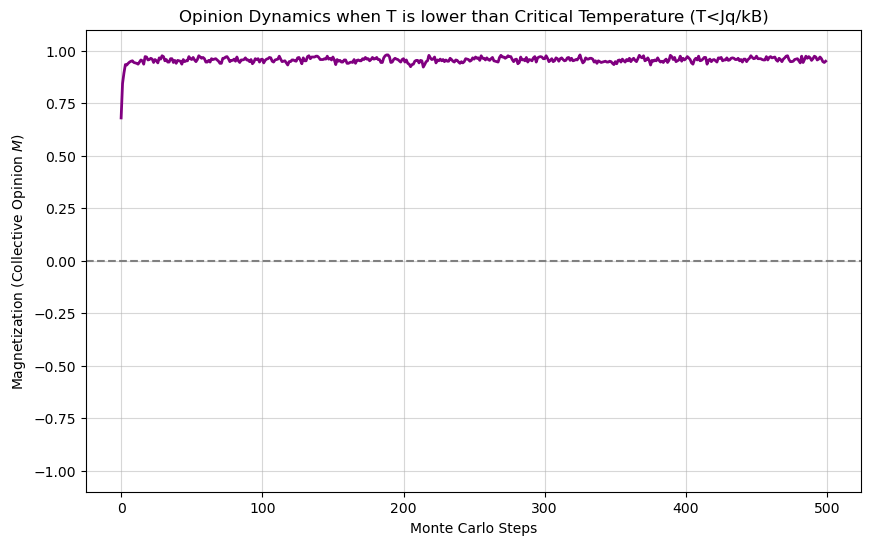

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_glauber_with_data(N_up_initial, N_down_initial, T, h, J, q, steps):
# 1. INITIALIZATION
    N = N_up_initial + N_down_initial
    
# Calculate probability of + and - opininion
    P_up = N_up_initial / N
    P_down = N_down_initial / N
    
# Calculate Initial Magnetization from the data
    M_awal = (N_up_initial - N_down_initial) / N
    
    print(f"INITIAL SPIN CONDITION")
    print(f"Total Population (N) : {N}")
    print(f"Probability +1    : {P_up:.4f}")
    print(f"Probability -1    : {P_down:.4f}")
    print(f"Initial M : {M_awal:.4f}\n")
    
# Assign spin randomly based on probability P_up dan P_down
    spins = np.array([1] * N_up_initial + [-1] * N_down_initial)
    np.random.shuffle(spins)

    N_up = N_up_initial
    N_down = N_down_initial
    
# Calculate the number of assigned up and down spin
    N_up = np.sum(spins == 1)
    N_down = np.sum(spins == -1)
    
    print(f"RANDOM ASSIGN SPIN CONDITION")
    print(f"N_up   : {N_up}")
    print(f"N_down : {N_down}")
    print(f"Actual M : {(N_up - N_down) / N:.4f}\n")

# 2. GLAUBER + MEAN-FIELD SIMULATION
    magnetization_history = []
    kB = 0.6 
    
    for step in range(steps):
        # Inner loop: N flip for each Monte Carlo Step
        for _ in range(N):
            M = (N_up - N_down) / N
            h_eff = h + J * q * M
            
            i = np.random.randint(0, N)
            sigma_i = spins[i]
            
            delta_E = 2 * sigma_i * h_eff
            
            exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))
            P_flip = 1.0 / (1.0 + exp_term)
            
            r = np.random.rand()
            if r < P_flip:
                spins[i] = -sigma_i
                
                if spins[i] == 1:
                    N_up += 1
                    N_down -= 1
                else:
                    N_up -= 1
                    N_down += 1
                    
        magnetization_history.append((N_up - N_down) / N)
        
    return magnetization_history

# Simulation Parameter
# Initial Number of Opinion 
Data_N_up = 750
Data_N_down = 250

# Ising model and Glauber Scheme Parameter
External_field = 0.0 
J_coupling = 0.3     
q_neighbors = 4.0    
Time_steps = 500
Temperature = 1

# Run the simulation
M_history = simulate_glauber_with_data(
    N_up_initial=Data_N_up, N_down_initial=Data_N_down, T=Temperature,
    h=External_field, J=J_coupling, 
    q=q_neighbors, steps=Time_steps
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(M_history, color='purple', linewidth=2)
plt.title("Opinion Dynamics when T is lower than Critical Temperature (T<Jq/kB)")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Magnetization (Collective Opinion $M$)")
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()

INITIAL SPIN CONDITION
Total Population (N) : 1000
Probability +1    : 0.7500
Probability -1    : 0.2500
Initial M : 0.5000

RANDOM ASSIGN SPIN CONDITION
N_up   : 750
N_down : 250
Actual M : 0.5000



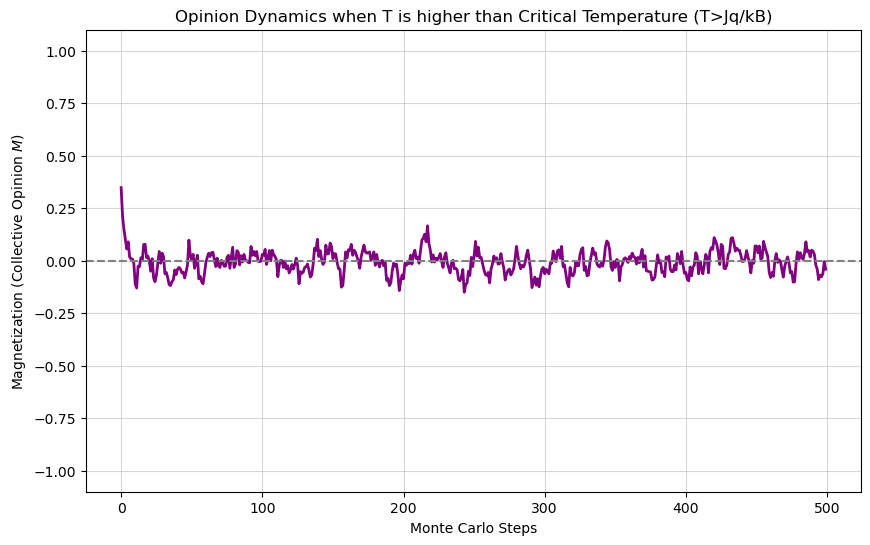

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_glauber_with_data(N_up_initial, N_down_initial, T, h, J, q, steps):
# 1. INITIALIZATION
    N = N_up_initial + N_down_initial
    
# Calculate probability of + and - opininion
    P_up = N_up_initial / N
    P_down = N_down_initial / N
    
# Calculate Initial Magnetization from the data
    M_awal = (N_up_initial - N_down_initial) / N
    
    print(f"INITIAL SPIN CONDITION")
    print(f"Total Population (N) : {N}")
    print(f"Probability +1    : {P_up:.4f}")
    print(f"Probability -1    : {P_down:.4f}")
    print(f"Initial M : {M_awal:.4f}\n")
    
# Assign spin randomly based on probability P_up dan P_down
    spins = np.array([1] * N_up_initial + [-1] * N_down_initial)
    np.random.shuffle(spins)

    N_up = N_up_initial
    N_down = N_down_initial
    
# Calculate the number of assigned up and down spin
    N_up = np.sum(spins == 1)
    N_down = np.sum(spins == -1)
    
    print(f"RANDOM ASSIGN SPIN CONDITION")
    print(f"N_up   : {N_up}")
    print(f"N_down : {N_down}")
    print(f"Actual M : {(N_up - N_down) / N:.4f}\n")

# 2. GLAUBER + MEAN-FIELD SIMULATION
    magnetization_history = []
    kB = 0.6 
    
    for step in range(steps):
        # Inner loop: N flip for each Monte Carlo Step
        for _ in range(N):
            M = (N_up - N_down) / N
            h_eff = h + J * q * M
            
            i = np.random.randint(0, N)
            sigma_i = spins[i]
            
            delta_E = 2 * sigma_i * h_eff
            
            exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))
            P_flip = 1.0 / (1.0 + exp_term)
            
            r = np.random.rand()
            if r < P_flip:
                spins[i] = -sigma_i
                
                if spins[i] == 1:
                    N_up += 1
                    N_down -= 1
                else:
                    N_up -= 1
                    N_down += 1
                    
        magnetization_history.append((N_up - N_down) / N)
        
    return magnetization_history

# Simulation Parameter
# Initial Number of Opinion 
Data_N_up = 750
Data_N_down = 250

# Ising model and Glauber Scheme Parameter
External_field = 0.0 
J_coupling = 0.3     
q_neighbors = 4.0    
Time_steps = 500
Temperature = 3.0

# Run the simulation
M_history = simulate_glauber_with_data(
    N_up_initial=Data_N_up, N_down_initial=Data_N_down, T=Temperature,
    h=External_field, J=J_coupling, 
    q=q_neighbors, steps=Time_steps
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(M_history, color='purple', linewidth=2)
plt.title("Opinion Dynamics when T is higher than Critical Temperature (T>Jq/kB)")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Magnetization (Collective Opinion $M$)")
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()